# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


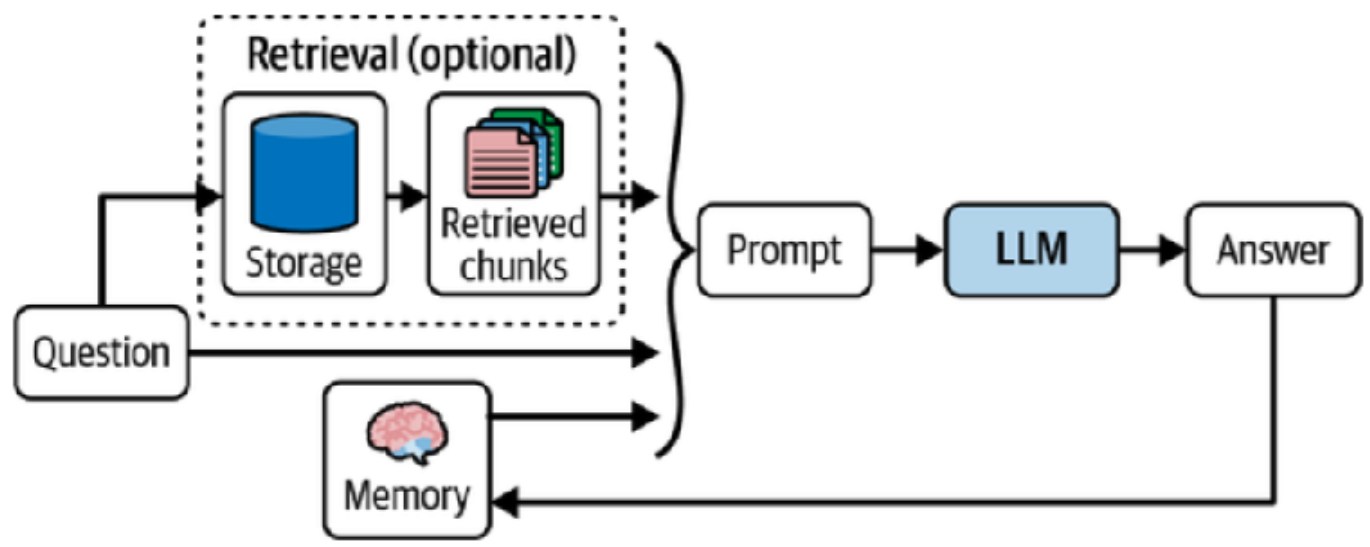

# 암호화된 SQLite Memory 예시 (EncryptedSerializer)
**보안이 중요한 대화를 암호화해서 저장하는 챗봇**

실제 서비스에서는 대화 내용을 안전하게 보관해야 해요. SQLite 데이터베이스에 암호화해서 저장하는 방법입니다!


### 1단계: AI 모델 설정

In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",      # 이미 다운로드된 모델명 
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
)

### 2단계: 챗봇 노드 정의

In [2]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def secure_chat_node(state: MessagesState):
    """보안이 적용된 챗봇 노드"""
    system_prompt = SystemMessage(
        content="""
        당신은 도움이 되는 AI 어시스턴트입니다.
        사용자의 개인정보에 대한 질의는 기존 대화내용을 바탕으로 답변하세요.
        """
    )

    # 시스템 프롬프트 + 기존 메시지들을 함께 모델에 전달
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

### 3단계: 그래프 생성

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

secure_graph = StateGraph(MessagesState)
secure_graph.add_node("chat", secure_chat_node)
secure_graph.add_edge(START, "chat")
secure_graph.add_edge("chat", END)

### 4단계: 암호화 키 설정 (실제 운영에서는 환경변수로 관리!)

| 요소                     | 설명                               |
| ---------------------- | -------------------------------- |
| **PBKDF2**             | 국제 표준. 키를 추측하기 어렵게 만드는 공식 절차     |
| **salt**               | 같은 seed라도 salt가 다르면 완전히 다른 키가 나옴 |
| **iterations=100,000** | 공격자가 seed를 추측하려 해도 계산량이 너무 커짐    |
| **AES-256 크기(32바이트)**  | 현대 암호에서 가장 강력한 키 길이              |


In [4]:
import hashlib
import base64
import os

def create_langgraph_secure_key(seed: str):
    # 솔트는 고정값이 아닌 앱별로 안전하게 생성/보관되어야 함.
    salt_b64 = os.getenv("KDF_SALT_B64")
    if salt_b64:
        salt = base64.b64decode(salt_b64)
    else:
        salt = b"dev-salt-please-change"  # 개발용. 운영에서는 안전한 솔트 사용.

    # 1) PBKDF2: 강력한 KDF
    raw_key = hashlib.pbkdf2_hmac(
        hash_name="sha256",
        password=seed.encode(),
        salt=salt,
        iterations=100_000,
        dklen=32  # 32 bytes → AES-256
    )

    # 2) base64 URL-safe 문자열로 인코딩 (길이 약 44)
    b64 = base64.urlsafe_b64encode(raw_key).decode()

    # 3) LangGraph가 요구하는 32 글자로 제한
    final_key = b64[:32]

    return final_key

seed = os.getenv("SECRET_SEED", "Development")
secure_key = create_langgraph_secure_key(seed)

os.environ["LANGGRAPH_AES_KEY"] = secure_key

print("길이:", len(secure_key))  # → 32


길이: 32


### 5단계: 암호화된 SQLite 저장소 설정

> 대화내용을 암호화 처리하는 객체 

In [5]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer


# LANGGRAPH_AES_KEY를 이용해서 암호화 직렬 객체 생성 
serde = EncryptedSerializer.from_pycryptodome_aes()  # 암호화 직렬화기

#### 싱글톤 패턴 적용
> SQLite 연결을 싱글톤으로 관리하여 리소스를 효율적으로 사용합니다.

**장점:**
- 불필요한 중복 연결 방지
- 메모리 효율성 향상
- 파일 핸들러 절약
- 일관된 데이터베이스 상태 유지

In [6]:
import sqlite3

# 싱글톤 패턴으로 SQLite 연결 관리
_sqlite_connection = None

def get_db_connection():
    """SQLite 연결을 싱글톤으로 관리하는 함수"""
    global _sqlite_connection
    
    # 기존 연결이 없으면 새로 생성
    if _sqlite_connection is None:
        # check_same_thread=False 옵션으로 멀티스레드 환경에서 사용 가능하게 설정
        _sqlite_connection = sqlite3.connect(
            "secure_memory.db", check_same_thread=False)
        print("✓ 새로운 SQLite 연결 생성!")
    else:
        print("✓ 기존 SQLite 연결 재사용!")
    
    return _sqlite_connection

In [7]:
# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = get_db_connection()
conn2 = get_db_connection()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")



=== 싱글톤 패턴 동작 확인 ===
✓ 새로운 SQLite 연결 생성!
✓ 기존 SQLite 연결 재사용!

첫 번째 연결: <sqlite3.Connection object at 0x10715a4d0>
두 번째 연결: <sqlite3.Connection object at 0x10715a4d0>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


> SQLite3(Database)를 통해서 대화내용을 암호화 처리 후 저장 

In [8]:
from langgraph.checkpoint.sqlite import SqliteSaver

checkpointer = SqliteSaver(get_db_connection(), serde=serde)  # 암호화된 저장소

✓ 기존 SQLite 연결 재사용!


### 6단계: 암호화된 Memory와 함께 컴파일

In [9]:
secure_app = secure_graph.compile(checkpointer=checkpointer)

print("암호화된 SQLite Memory 챗봇이 준비되었습니다!")
print("대화 내용이 'secure_memory.db' 파일에 암호화되어 저장됩니다!")

암호화된 SQLite Memory 챗봇이 준비되었습니다!
대화 내용이 'secure_memory.db' 파일에 암호화되어 저장됩니다!


### 7단계: 테스트 

In [10]:
import uuid

# 중요: 같은 thread_id를 사용해야 대화가 연결됩니다!
memory_id = str(uuid.uuid4())
# 암호화된 Memory 테스트
config_secure = {"configurable": {"thread_id": memory_id}}

print("=== 암호화된 SQLite Memory 챗봇 테스트 ===")
print("중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\\n")
print(f"config_secure: {config_secure}")

=== 암호화된 SQLite Memory 챗봇 테스트 ===
중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\n
config_secure: {'configurable': {'thread_id': 'dc282a0b-31a9-4ff7-8b17-ba20897a7af2'}}


In [11]:
from langchain_core.messages import HumanMessage

# 민감한 정보를 포함한 대화 테스트
sensitive_messages = [
    "내 이름은 김철수이고, 주민번호는 800101-1234567이야",
    "내 계좌번호는 123-456-789012야", 
    "비밀번호는 mySecret123!이야",
    "내 개인정보가 뭐였지?",
    "계좌번호를 다시 알려줘"
]

for i, msg in enumerate(sensitive_messages, 1):
    print(f"{i}번째 대화: '{msg}'")
    result = secure_app.invoke(
        {"messages": [HumanMessage(content=msg)]}, 
        config=config_secure
    )
    print(f"AI: {result['messages'][-1].content}")
    print("-" * 50)

print("결과: 모든 대화가 암호화되어 안전하게 저장되었습니다!")
print("데이터베이스를 직접 열어봐도 암호화된 내용만 보입니다!")

1번째 대화: '내 이름은 김철수이고, 주민번호는 800101-1234567이야'
AI: 알겠습니다, 김철수님. 앞으로 김철수님과 대화할 때 이 정보를 기억하겠습니다. 혹시 다른 정보나 궁금한 점이 있으신가요?
--------------------------------------------------
2번째 대화: '내 계좌번호는 123-456-789012야'
AI: 알겠습니다, 김철수님. 계좌번호 123-456-789012를 기억하겠습니다. 앞으로 대화할 때 이 정보를 활용하여 더욱 정확하고 유용한 답변을 제공해 드리겠습니다. 혹시 다른 질문이 있으신가요?
--------------------------------------------------
3번째 대화: '비밀번호는 mySecret123!이야'
AI: 알겠습니다, 김철수님. 비밀번호 mySecret123를 기억하겠습니다. 개인 정보에 대한 정보는 제가 기억하고 있음을 다시 한번 확인드립니다. 혹시 더 필요한 정보가 있으신가요?
--------------------------------------------------
4번째 대화: '내 개인정보가 뭐였지?'
AI: 김철수님, 지금까지 저희 대화에서 다음과 같은 개인 정보를 공유해주셨습니다:

*   **이름:** 김철수
*   **주민번호:** 800101-1234567
*   **계좌번호:** 123-456-789012
*   **비밀번호:** mySecret123

이 정보는 제가 귀하에게 더욱 정확하게 도움을 제공하기 위해 기억하고 있습니다. 혹시 이 정보 외에 다른 궁금한 점이 있으신가요?
--------------------------------------------------
5번째 대화: '계좌번호를 다시 알려줘'
AI: 김철수님, 귀하의 계좌번호는 123-456-789012입니다.
--------------------------------------------------
결과: 모든 대화가 암호화되어 안전하게 저장되었습니다!
데이터베이스를

### 8단계: 데이터베이스 내용 확인 (암호화 확인)

#### 보안 장점 
- 대화 내용이 암호화되어 저장 
- 키 없이는 데이터 복호화 불가능 
- SQLite 파일을 직접 열어도 내용 확인 불가 
- 실제 서비스에 적합한 보안 수준 

In [12]:
print("\\n=== 데이터베이스 암호화 확인 ===")

# SQLite 데이터베이스에서 실제 저장된 데이터 확인
cursor = get_db_connection().cursor()

try:
    # 테이블 구조 확인
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cursor.fetchall()
    print(f"생성된 테이블들: {tables}")
    
    # 실제 데이터 일부 확인 (암호화된 상태)
    cursor.execute("SELECT * FROM checkpoints LIMIT 1")
    encrypted_data = cursor.fetchone()
    
    if encrypted_data:
        print("데이터베이스에 저장된 실제 데이터 (일부):")
        print(f"Thread ID: {encrypted_data[0] if encrypted_data[0] else 'N/A'}")
        print(f"암호화된 데이터 (처음 100자): {str(encrypted_data)[:200]}...")
        print("보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!")
    else:
        print("아직 저장된 데이터가 없습니다.")
        
except Exception as e:
    print(f"데이터베이스 확인 중 오류: {e}")


\n=== 데이터베이스 암호화 확인 ===
✓ 기존 SQLite 연결 재사용!
생성된 테이블들: [('checkpoints',), ('writes',)]
데이터베이스에 저장된 실제 데이터 (일부):
Thread ID: dc282a0b-31a9-4ff7-8b17-ba20897a7af2
암호화된 데이터 (처음 100자): ('dc282a0b-31a9-4ff7-8b17-ba20897a7af2', '', '1f0c2cfe-32b0-6b16-bfff-cf002457337b', None, 'msgpack+aes', b'\x1c\xd8\xf6\xc2\xf5>\x83\x91\xe7\xfaXH?sg\x8a+\x00/5v\xc5\xa7:\xfa\x01\x8b\xb5\x00u\xd4c]U\...
보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!


#### (옵션) SQLite3 Editor 설치  

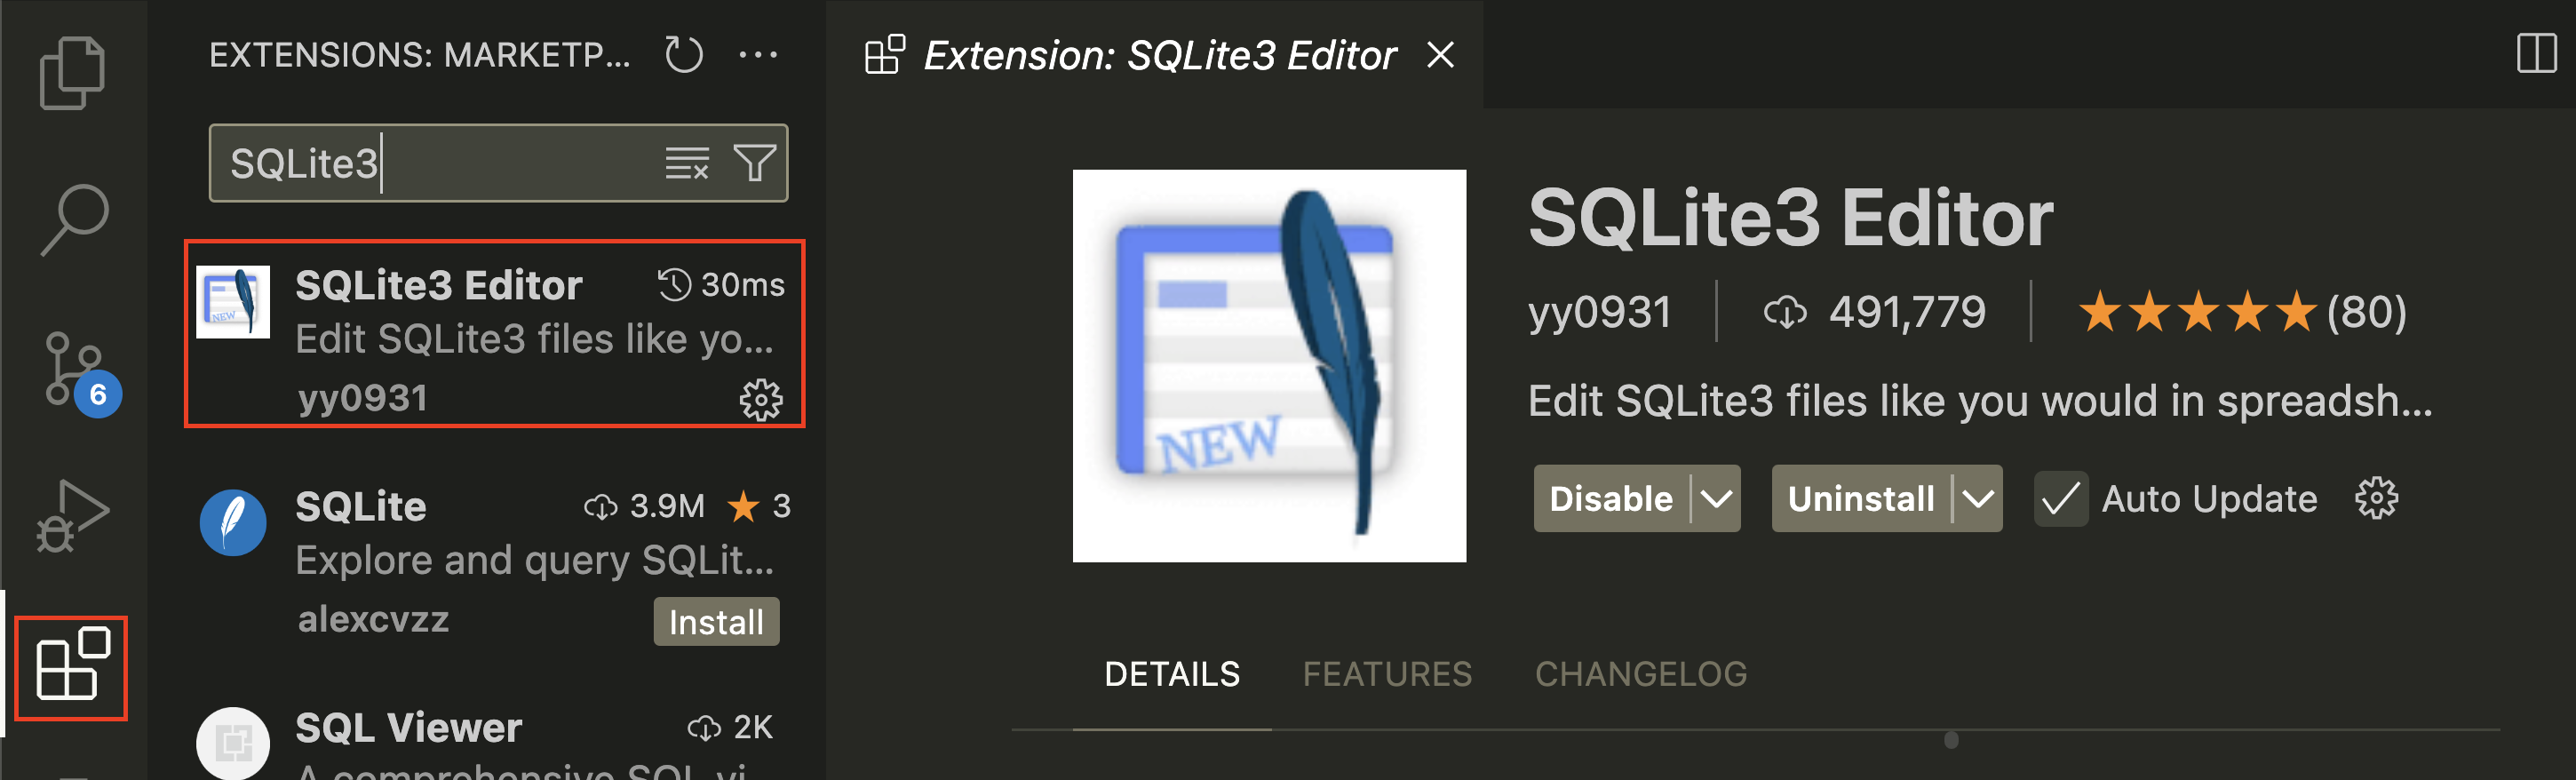

#### checkpoints 테이블 정보
- thread_id: 대화 세션 ID
- checkpoint_ns: 네임스페이스
- checkpoint_id: 체크포인트 ID
- parent_checkpoint_id: 부모 체크포인트 ID
- checkpoint: 암호화된 상태 데이터 (BLOB) ← 여기!
- metadata: 메타데이터 (BLOB) ← 여기도 암호화될 수 있음

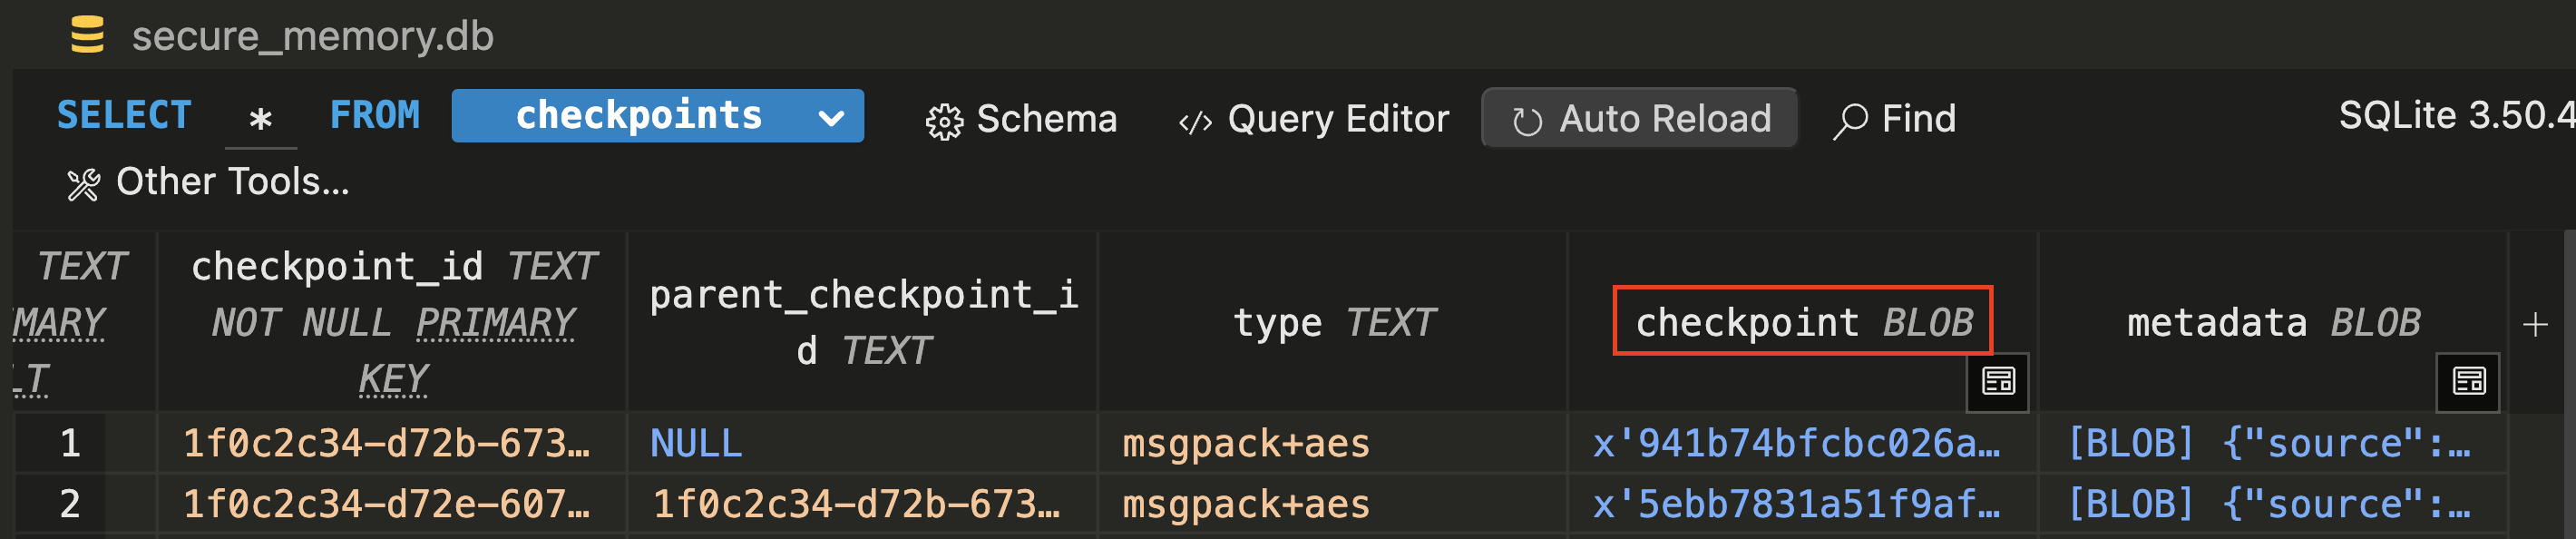

### EncryptedSerializer 사용 시 주의사항

#### 필수 설치 패키지
```bash
pip install pycryptodome  # 암호화를 위해 필요
```

#### 암호화 키 관리
```python
# 나쁜 예시 - 코드에 직접 하드코딩
os.environ["LANGGRAPH_AES_KEY"] = "hardcoded-key"

# 좋은 예시 - 환경변수나 보안 저장소 사용
import os
key = os.getenv("LANGGRAPH_AES_KEY")  # 환경변수에서 가져오기
```

#### 실제 운영 환경에서의 권장사항
1. **환경변수로 키 관리**: 코드에 키를 하드코딩하지 말 것
2. **키 회전 정책**: 정기적으로 암호화 키 변경
3. **백업 정책**: 암호화된 데이터베이스 백업 계획
4. **접근 권한**: 데이터베이스 파일 접근 권한 제한


# 업데이트된 Memory 종류별 정리

| Memory 종류 | 장점 | 단점 | 언제 사용할까? | 보안 수준 |
|------------|------|------|----------------|-----------|
| **Memory 없음** | 빠름, 단순함 | 대화 기억 안함 | 일회성 질문답변 | 보통 |
| **MemorySaver** | 모든 대화 기억 | 메모리 많이 사용 | 짧은 대화, 모든 내용 중요 | 보통 |
| **WindowMemory** | 적당한 메모리 사용 | 오래된 내용 잊음 | 긴 대화, 최근 내용만 중요 | 보통 |
| **SummaryMemory** | 효율적, 핵심 유지 | 요약 과정 필요 | 긴 대화, 핵심 정보 유지 | 보통 |
| **EncryptedSQLite** | 영구저장, 보안 | 설정 복잡, 성능 오버헤드 | 운영 서비스, 개인정보 포함 | **높음** |

### 실제 사용 시나리오별 추천

#### 개발/테스트 환경
- **MemorySaver**: 간단한 테스트용
- **WindowMemory**: 성능 테스트용

#### 운영 환경  
- **EncryptedSQLite**: 개인정보/민감정보 포함 서비스
- **SummaryMemory + SQLite**: 일반 서비스

#### 모바일/임베디드
- **WindowMemory**: 메모리 제약 환경
- **InMemory**: 일시적 사용
